# <center> 实验3：Pandas与数据可视化实验</center>

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

### 题目1：Series创建与索引

创建一个Pandas Series，数据为 `[10, 20, 30, 40, 50]`，索引为 `[‘a’, ‘b’, ‘c’, ‘d’, ‘e’]`。
1.  通过标签索引获取值 `‘c’` 和 `‘e’` 对应的值。
2.  通过位置切片获取第2到第4个（位置从0开始）元素。
3.  通过布尔索引筛选出所有大于25的值。


In [3]:
# 创建Series对象
s = pd.Series([10, 20, 30, 40, 50], index = ['a', 'b', 'c', 'd', 'e'])
#task1
print("s['c']:",s['c'])
print("s[['c','e']]:") 
print(s[['c','e']])
#task2
print("s[1:4]:")
print(s[1:4])
#task3
print("s[s>25]:")
print(s[s>25])

s['c']: 30
s[['c','e']]:
c    30
e    50
dtype: int64
s[1:4]:
b    20
c    30
d    40
dtype: int64
s[s>25]:
c    30
d    40
e    50
dtype: int64


### 题目2：Series基本运算与处理缺失值

有两个Series：
-  s1数据为 `[1, 2, 3, 4]`，索引为 `[‘a’, ‘b’, ‘c’, ‘d’]` 
-  s2数据为 `[10, 20, 30, 40]`，索引为 `[‘b’, ‘c’, ‘d’, ‘e’])`

计算两者的和。

In [ ]:
s1 = pd.Series([1, 2, 3, 4, ], index = ['a', 'b', 'c', 'd'])
s2 = pd.Series([5, 6, 7, 8], index = ['b', 'c', 'd', 'e'])

# 将缺失值视为0，再相加
sum_series = s1.add(s2, fill_value=0)

print("s1 + s2:")
print(sum_series)


s1 + s2:
a     1.0
b     7.0
c     9.0
d    11.0
e     8.0
dtype: float64


### 题目3：DataFrame数据分组与聚合
给定一个DataFrame df，包含列 Category 和 Value，按 Category 分组并计算每组的平均值。

In [6]:
# 构造数据
df = pd.DataFrame({
    'Category': ['A','B','C','A','B','C','A','B','C','A'],
    'Value':    [61, 24, 81, 70, 30, 92, 96, 84, 84, 97]
})

# 按category分组并计算平均值
group_mean = df.groupby('Category')['Value'].mean()

print("原始DataFrame:")
print(df)
print("按Category分组后的平均值：")
print(group_mean)

原始DataFrame:
  Category  Value
0        A     61
1        B     24
2        C     81
3        A     70
4        B     30
5        C     92
6        A     96
7        B     84
8        C     84
9        A     97
按Category分组后的平均值：
Category
A    81.000000
B    46.000000
C    85.666667
Name: Value, dtype: float64


### 题目4：DataFrame数据透视表
给定一个DataFrame df，包含列 Date、Category 和 Value，创建以 Date 为行、Category 为列的数据透视表，并计算 Value 的总和。

In [7]:
# 构造数据
df = pd.DataFrame({
    'Date': pd.to_datetime(['2023-01-01', '2023-01-01', '2023-01-02', '2023-01-02']),
    'Category': ['A', 'B', 'A', 'B'],
    'Value': [1, 2, 3, 4]
})

# 创建以 Date 为行、Category 为列、Value 求和的数据透视表
pivot_table = df.pivot_table(index='Date', columns='Category', values='Value', aggfunc='sum', fill_value=0)

print("原始df:")
print(df)
print("数据透视表（Date 行，Category 列，Value 求和）:")
print(pivot_table)

原始df:
        Date Category  Value
0 2023-01-01        A      1
1 2023-01-01        B      2
2 2023-01-02        A      3
3 2023-01-02        B      4
数据透视表（Date 行，Category 列，Value 求和）:
Category    A  B
Date            
2023-01-01  1  2
2023-01-02  3  4


### 题目5：数据分箱
给定一个DataFrame `df`
1. 将列 `Value` 分为3个等宽的区间，并添加新列 `Bin1` 表示区间。
2. 将列 `Value` 分为3个等深的区间，并添加新列 `Bin2` 表示区间。

In [9]:
# 构造数据
df = pd.DataFrame({
    'Value': [61, 24, 81, 70, 30, 92, 96, 84, 84, 97]
})

# task1 等宽分箱 - 将数据分成3个等宽区间
df['Bin1'] = pd.cut(df['Value'], bins=3)

# task2 等深分箱 - 将数据分成三个等深区间
df['Bin2'] = pd.qcut(df['Value'], q=3)

print("分箱后的DataFrame:")
print(df)

分箱后的DataFrame:
   Value              Bin1            Bin2
0     61  (48.333, 72.667]  (23.999, 70.0]
1     24  (23.927, 48.333]  (23.999, 70.0]
2     81    (72.667, 97.0]    (70.0, 84.0]
3     70  (48.333, 72.667]    (70.0, 84.0]
4     30  (23.927, 48.333]  (23.999, 70.0]
5     92    (72.667, 97.0]    (84.0, 97.0]
6     96    (72.667, 97.0]    (84.0, 97.0]
7     84    (72.667, 97.0]    (70.0, 84.0]
8     84    (72.667, 97.0]    (70.0, 84.0]
9     97    (72.667, 97.0]    (84.0, 97.0]


### 题目6：  加载58同城房源销售数据.

In [18]:
import os

path = os.path.join('data', '58.xlsx')  # 相对路径：data/58.xlsx
try:
    # 用panda的read_excel工具尝试打开
    df58 = pd.read_excel(path)
except FileNotFoundError:
    print(f"未找到文件: {path}")
    if os.path.isdir('data'):
        print("data 目录下文件：", os.listdir('data'))
    raise


print(df58)

    price  housearea houseoriented  shishu  housefloor housetype
0   50000        100             南       2           3        公寓
1   73513        123            南北       3           4      连排别墅
2   23434         86             北       3           5        公寓
3   45623         45             北       2           8       独立屋
4   18573         65             南       2           7      连排别墅
5   23567         74             南       2           1        公寓
6   85764         89             北       3           9       独立屋
7   63547         56             北       2           8      连排别墅
8   85638         76             南       3          12        公寓
9   23452         75            南北       3           2       独立屋
10  76543         64            南北       2          17        公寓
11  20947         53             北       2          16      连排别墅
12  84461         42            南北       1           4        公寓
13  81746         89            南北       3           3        公寓
14  37461         78     

### 题目7： 房价分布分析 - 直方图
分析58同城平台上房产价格的分布情况，使用等宽区间划分方法将价格范围均匀分为8个区间，了解各价格区间的房源数量分布特征。

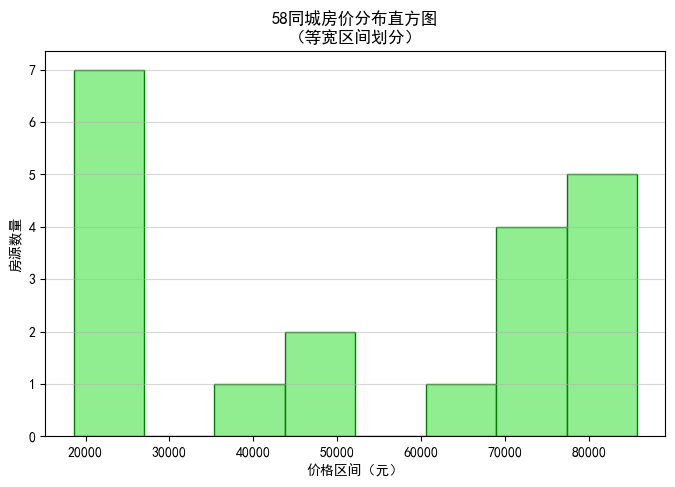

In [42]:
# df58 已在题目6中加载，并包含 price 列

# 设置中文字体和负号显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# 确保 price 为数值类型，丢弃无法转换的行
df58['price'] = pd.to_numeric(df58['price'], errors='coerce')
prices = df58['price'].dropna()

# 使用等宽8个区间绘制直方图
bins = 8
# 设置画布尺寸
plt.figure(figsize=(8,5))
# 直方图创建
n, bin_edges, patches = plt.hist(prices, bins=bins, color='lightgreen', edgecolor='green')
# 标签、标题等描述
plt.xlabel('价格区间（元）')
plt.ylabel('房源数量')
plt.title('58同城房价分布直方图\n（等宽区间划分）')
# 网格线
plt.grid(axis='y', alpha=0.5, zorder=0)
plt.show()

### 题目8： 户型与价格关系 - 柱状图
比较不同户型（公寓、连排别墅、独立屋）的平均价格,绘制各户型的平均价格柱状图

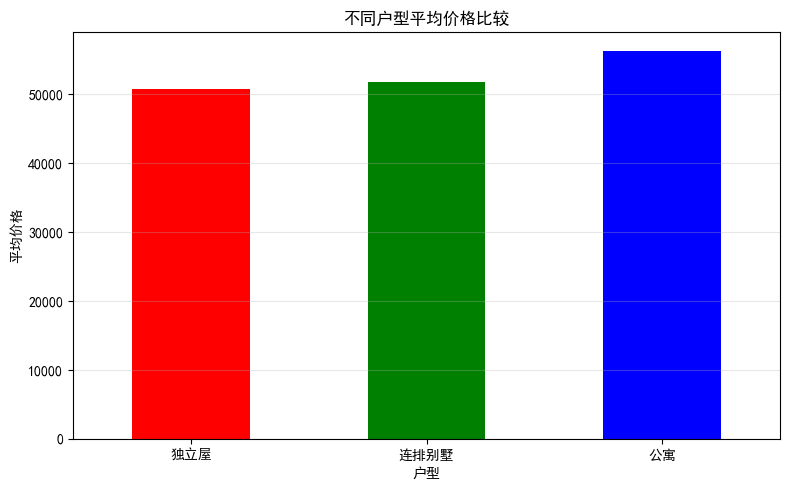

In [48]:
# 依赖：前面题目6已加载 df58

# 检查列是否存在
if {'price', 'housetype'}.issubset(df58.columns):
    # 确保 price 为数值类型
    df58['price'] = pd.to_numeric(df58['price'], errors='coerce')
    # 计算各户型平均价格并按价格升序排列（便于可视化）
    avg_price_by_type = df58.groupby('housetype')['price'].mean().sort_values()

    # 设置中文字体以防乱码
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'sans-serif']
    plt.rcParams['axes.unicode_minus'] = False

    # 绘制柱状图
    plt.figure(figsize=(8,5))
    avg_price_by_type.plot(kind='bar', color=['red','green','blue'][:len(avg_price_by_type)])
    # 标签和标题
    plt.xticks(rotation=0) #旋转，不然字会竖起来
    plt.xlabel('户型')
    plt.ylabel('平均价格')
    plt.title('不同户型平均价格比较')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("数据中缺少 'price' 或 'housetype' 列，无法计算各户型平均价格。")


### 题目9： 房屋面积与价格关系 - 散点图
探索房屋面积与价格的相关关系，绘制面积-价格的散点图

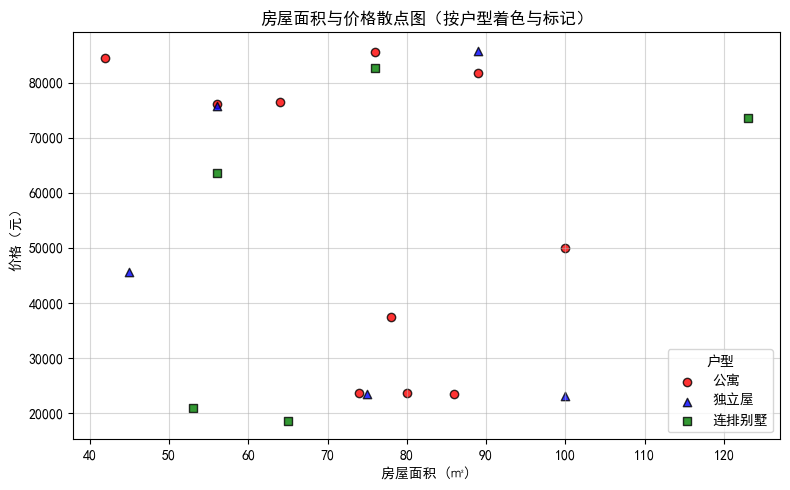

In [60]:
import numpy as np

# 确保数值类型并丢弃缺失值
df58['price'] = pd.to_numeric(df58['price'], errors='coerce')
df58['housearea'] = pd.to_numeric(df58['housearea'], errors='coerce')
df_clean = df58.dropna(subset=['price', 'housearea'])

# 计算相关系数
corr = df_clean['housearea'].corr(df_clean['price'])

# 绘图设置
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(8,5))

# 如果存在 housetype，则对每类分别绘制，指定三种标记和颜色
if 'housetype' in df_clean.columns:
    # 指定三类对应的颜色和标记（如不存在某类则自动扩展）
    marker_map = {
        '公寓': ('red', 'o'),         # 红色圆点
        '连排别墅': ('green', 's'),    # 绿色正方形
        '独立屋': ('blue', '^'),      # 蓝色三角形
    }
    # 对每个户型分组绘制
    for ht, group in df_clean.groupby('housetype'):
        color, marker = marker_map.get(ht, ('gray', 'x'))  # 默认样式
        plt.scatter(group['housearea'], group['price'],
                    c=color, marker=marker, edgecolor='k', alpha=0.8, label=str(ht))
else:
    # 无 housetype，全部用蓝色圆点
    plt.scatter(df_clean['housearea'], df_clean['price'],
                c='blue', marker='o', edgecolor='k', alpha=0.7, label='数据点')
    


plt.xlabel('房屋面积 (㎡)')
plt.ylabel('价格（元）')
plt.title('房屋面积与价格散点图（按户型着色与标记）')
# 设置图例位置为右下角
plt.legend(loc='lower right', title='户型' if 'housetype' in df_clean.columns else None)
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

### 题目10： 楼层分布分析 - 曲线图
分析楼层高度与房价的关系趋势，绘制楼层与平均价格的折线图

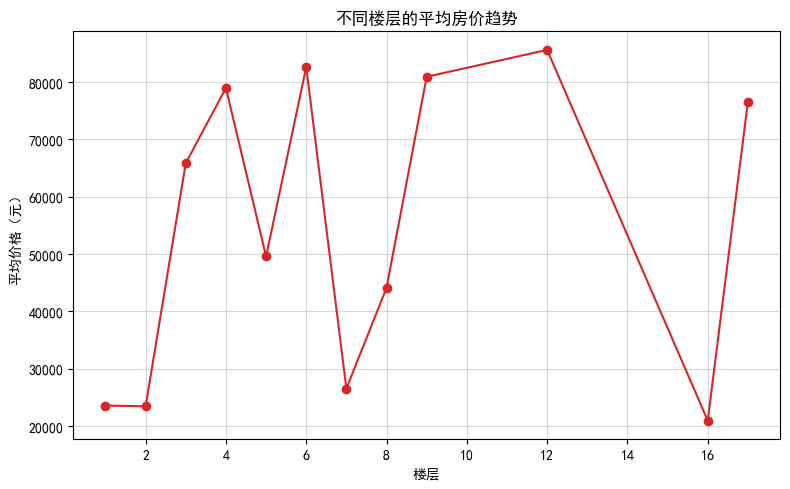

In [66]:
# 依赖：df58 已在题目6中加载

# 确保 price 为数值
df58['price'] = pd.to_numeric(df58['price'], errors='coerce')

# 尝试将 housefloor 转为数值（优先直接转换，失败则尝试从字符串中提取数字）
df58['housefloor_num'] = pd.to_numeric(df58.get('housefloor'), errors='coerce')
if df58['housefloor_num'].isna().all():
    # 提取第一个出现的数字（如 "3/10层"、"低层(共6层)" 等）
    df58['housefloor_num'] = df58['housefloor'].astype(str).str.extract(r'(\d+)').astype(float)

# 丢弃 price 或 housefloor_num 缺失的行
df_floor = df58.dropna(subset=['price', 'housefloor_num']).copy()

if df_floor.empty:
    print("没有可用于楼层分析的数据（price 或 housefloor 缺失或无法解析）。")
else:
    # 按楼层分组计算平均价格与样本量
    floor_stats = df_floor.groupby('housefloor_num')['price'].agg(['mean','count']).reset_index().sort_values('housefloor_num')
    floor_stats.rename(columns={'housefloor_num':'floor','mean':'avg_price','count':'n'}, inplace=True)


    # 绘图
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'sans-serif']
    plt.rcParams['axes.unicode_minus'] = False
    plt.figure(figsize=(8,5))
    plt.plot(floor_stats['floor'], floor_stats['avg_price'], marker='o', linestyle='-', color='tab:red')
    # 标签和标题
    plt.xlabel('楼层')
    plt.ylabel('平均价格（元）')
    plt.title('不同楼层的平均房价趋势')
    plt.grid(alpha=0.5)
    plt.tight_layout()
    plt.show()
